In [34]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [35]:
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df_cleaned = pd.read_csv('data/df_cleaned.csv')
display(df_cleaned.head())

c:\Users\kims\Documents


FileNotFoundError: [Errno 2] No such file or directory: 'data/df_cleaned.csv'

In [ ]:
df_cleaned_copy = df_cleaned.copy()

# 가격(price)과 평점 측면에서 살펴보기! 

주요 변수: 
    
    1) host_listings_count(호스트의 전체 등록 숙소 수) 
       또는 host_total_listings_count(에어비앤비 시스템에 등록된 호스트의 '모든' 숙소 개수)
    
    2) host_verifications(호스트가 본인인증위해 사용한 수단)
    3) calculated_host_listings_count
    4) calculated_host_listings_count_entire_homes => 독채/아파트
    5) calculated_host_listings_count_private_rooms => 개인실 수(거실/화장실 공유)
    6) calculated_host_listings_count_shared_rooms => 다인실 수(게스트 하우스)

# calculated_host_listings_count에 대한 분석

# 윤범님 여기예요! 
-1 => 밑에 2가 끝이에요:)

In [ ]:
# calculated_host_listings_count 컬럼의 범위로 데이터 묶기
# 개인 호스트 : 숙소 1개 / 중소형 호스트: 숙소 2~10개 / 대형 호스트: 숙소 11개 이상
def categorize_host(listings_count):
    if listings_count == 1:
        return '개인 호스트'
    elif 2 <= listings_count <= 10:
        return '중소형 호스트'
    else:
        return '대형 호스트'
df_cleaned_copy['host_category'] = df_cleaned_copy['calculated_host_listings_count'].apply(categorize_host)
# host_category 컬럼의 범주별로 데이터 묶기
host_category_counts = df_cleaned_copy['host_category'].value_counts()
print(host_category_counts)

host_category
개인 호스트     7967
중소형 호스트    7658
대형 호스트     6683
Name: count, dtype: int64



호스트 카테고리 비율: host_category
개인 호스트     35.713645
중소형 호스트    34.328492
대형 호스트     29.957863
Name: count, dtype: float64


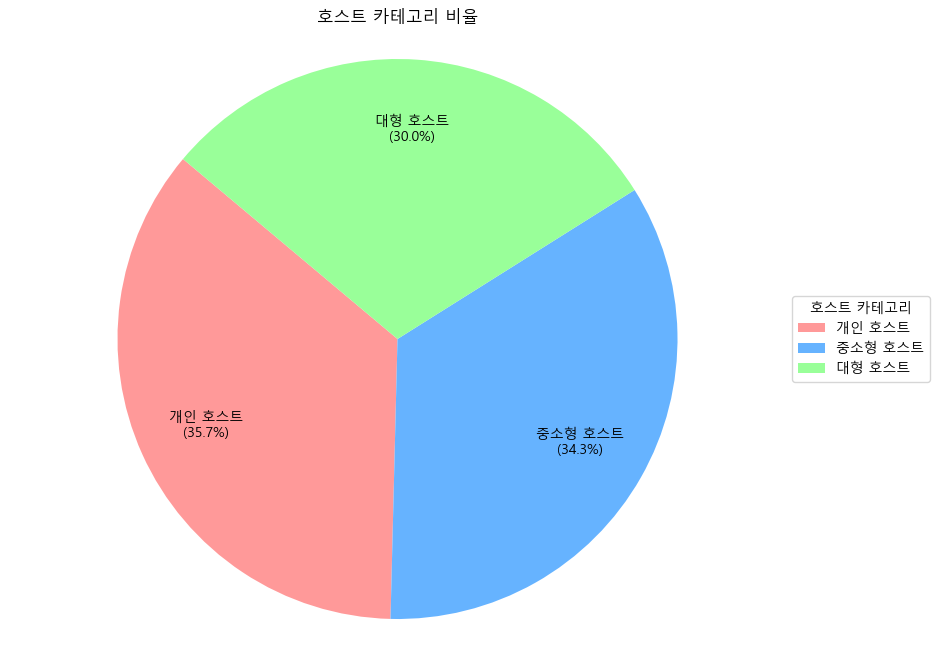

In [ ]:
# 개인 호스트, 중소형 호스트, 대형 호스트의 비율 계산
total_hosts = host_category_counts.sum()
host_category_ratios = (host_category_counts / total_hosts) * 100
print(f"\n호스트 카테고리 비율: {host_category_ratios}")

# 파이그래프로 시각화
fig, ax = plt.subplots(figsize=(10, 8))
wedges, texts, autotexts = ax.pie(host_category_counts, autopct='%1.1f%%', startangle=140, pctdistance=0.75, colors= ['#ff9999','#66b3ff','#99ff99'])
# 파이 안에 "이름+비율" 표시
for i, a in enumerate(autotexts):
    label = host_category_counts.index[i]
    current_pct = a.get_text()
    a.set_text(f"{label}\n({current_pct})")
    a.set_fontsize(10)
    a.set_color('black')
# 범례 추가
ax.legend(wedges, host_category_counts.index, title="호스트 카테고리", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.title('호스트 카테고리 비율')
plt.axis('equal')  # 원이 둥글게 보이도록 설정
plt.show()

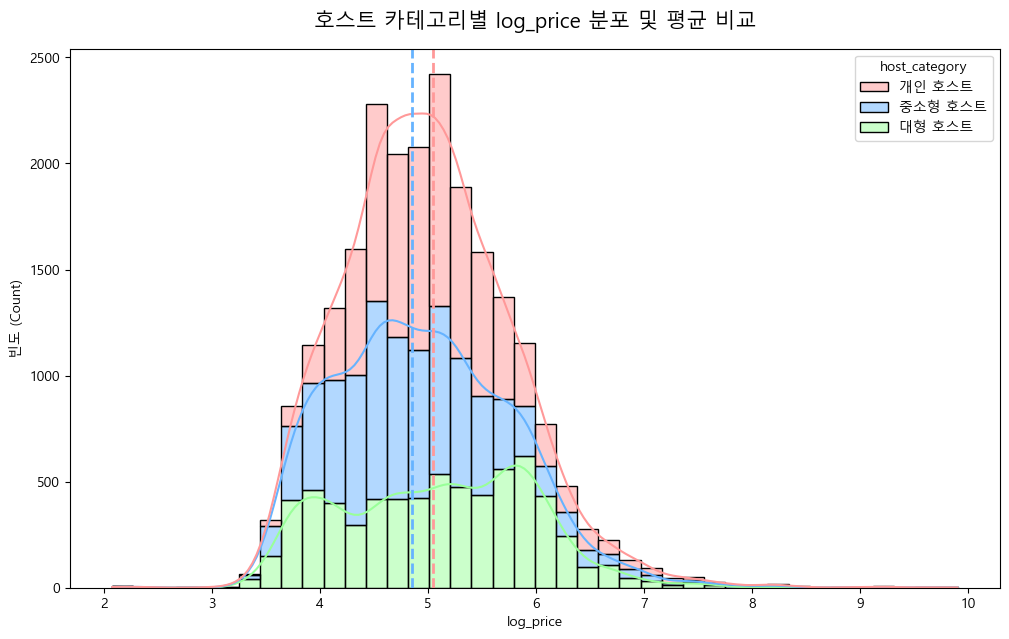

In [ ]:
# 호스트 카테고리별 log_price 분포 시각화
plt.figure(figsize=(12, 7))
sns.histplot(data=df_cleaned_copy, x='log_price', hue='host_category', 
             multiple='stack', kde=True, bins=40, 
             palette=['#ff9999','#66b3ff','#99ff99'], alpha=0.5)

# 각 카테고리별 평균값 계산 및 수직선(axvline) 추가
colors = ['#ff9999','#66b3ff','#99ff99']
categories = ['개인 호스트', '중소형 호스트', '기업형 호스트'] 

for i, cat in enumerate(categories):
    host_mean_val = df_cleaned_copy[df_cleaned_copy['host_category'] == cat]['log_price'].mean()
    
    # 수직선 그리기
    plt.axvline(host_mean_val, color=colors[i], linestyle='--', linewidth=2)

# 4. 라벨 및 타이틀 설정
plt.title('호스트 카테고리별 log_price 분포 및 평균 비교', fontsize=15, pad=15)
plt.xlabel('log_price')
plt.ylabel('빈도 (Count)')

plt.show()

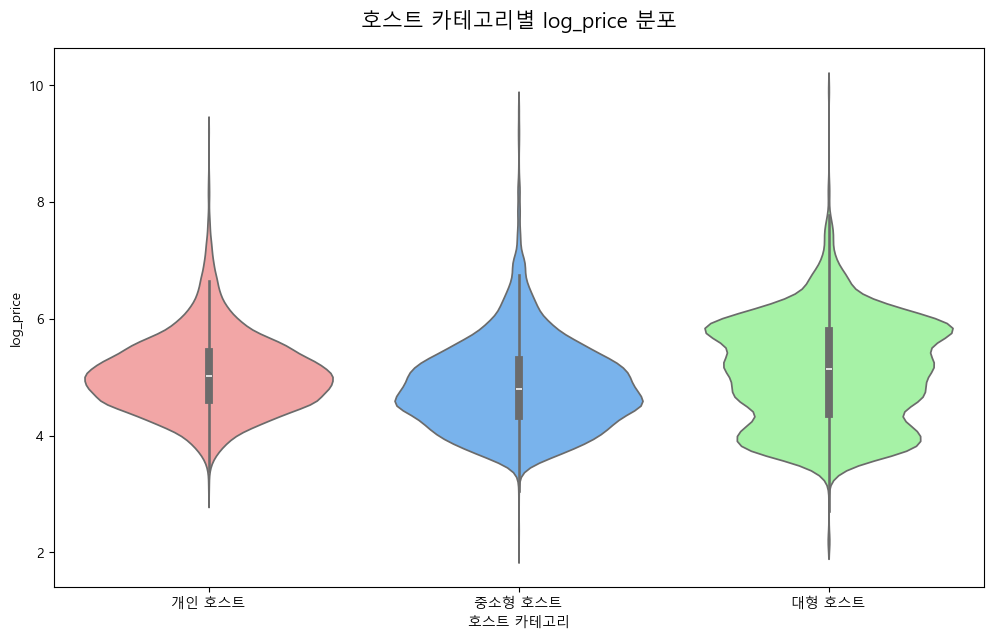

In [ ]:
#바이올렛 도표로 시각화
plt.figure(figsize=(12, 7))
sns.violinplot(data=df_cleaned_copy, x='host_category', y='log_price', palette=['#ff9999','#66b3ff','#99ff99'])
plt.title('호스트 카테고리별 log_price 분포', fontsize=15, pad=15)
plt.xlabel('호스트 카테고리')
plt.ylabel('log_price')
plt.show()

# 윤범님 여기예요! - 2

In [ ]:
# 호스트 카테고리별 에어비앤비 비노출/노출 호스트 숙소 분포 시각화
 # 개인 호스트/중소형 호스트/기업형 호스트의 비노출/노출 숙소 분포 시각화

# 에어비앤비 비노출 호스트 숙소 분포 확인
 # host_total_listings_count: 호스트가 보유한 총 숙소 수
 # host_listings_count: 호스트가 보유한 노출 숙소 수
# 비노출 숙소 개수 컬럼 생성
# host_non_exposure = host_total_listings_count - host_listings_count
df_cleaned_copy['host_non_exposure'] = df_cleaned_copy['host_total_listings_count'] - df_cleaned_copy['host_listings_count']
 # No: 비노출 숙소가 있는 호스트, Yes: 비노출 숙소가 없는 호스트
df_cleaned_copy['has_non_exposure'] = df_cleaned_copy['host_non_exposure'].apply(lambda x: 'No' if x > 0 else 'Yes')
df_cleaned_copy['has_non_exposure'].value_counts()

has_non_exposure
No     14144
Yes     8164
Name: count, dtype: int64

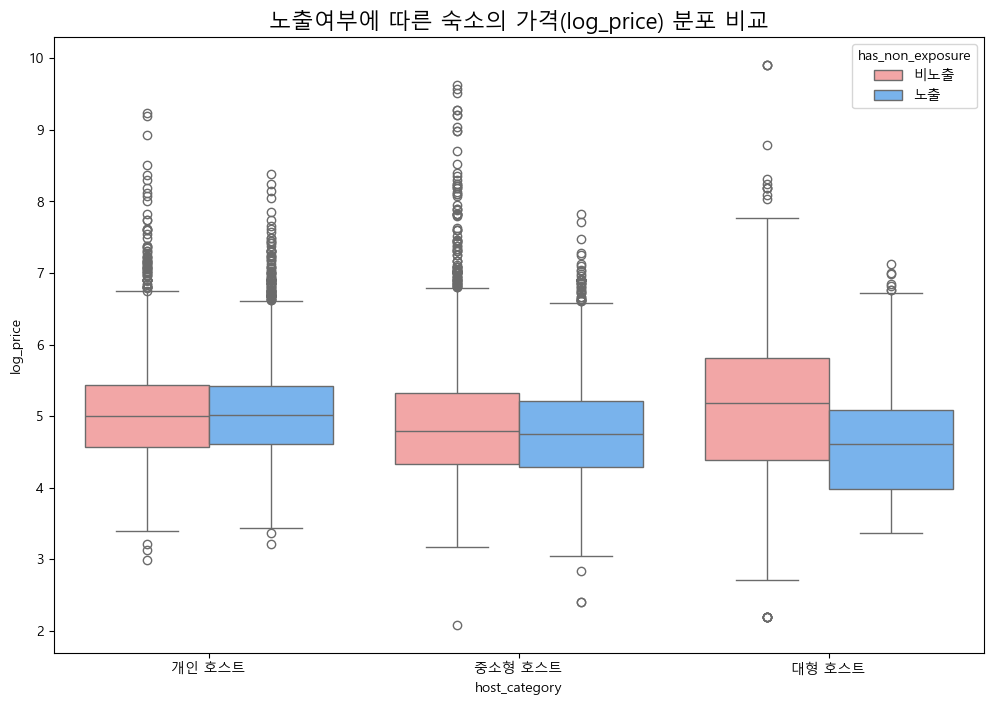

In [ ]:
# 호스트 카테고리별 에어비앤비 비노출/노출 호스트 숙소 분포 시각화
 # 개인 호스트/중소형 호스트/기업형 호스트의 비노출/노출 숙소 분포 시각화

# 에어비앤비 비노출 호스트 숙소 분포 확인
 # host_total_listings_count: 호스트가 보유한 총 숙소 수
 # host_listings_count: 호스트가 보유한 노출 숙소 수
# 비노출 숙소 개수 컬럼 생성
df_cleaned_copy['has_non_exposure'] = df_cleaned_copy['host_non_exposure'].apply(lambda x: '비노출' if x > 0 else '노출')

# 비노출 숙소 유무에 따른 가격 분포 시각화
plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_cleaned_copy, 
    x='host_category', 
    y='log_price', 
    hue='has_non_exposure', # '개수'가 아닌 '유무'로 비교
    palette=['#ff9999', '#66b3ff']
)

plt.title('노출여부에 따른 숙소의 가격(log_price) 분포 비교', fontsize=16)
plt.show()

In [ ]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

model = smf.ols('log_price ~ host_category * has_non_exposure', data=df_cleaned_copy).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                                      sum_sq       df           F  \
host_category                     219.254301      2.0  187.652810   
has_non_exposure                   24.577306      1.0   42.069876   
host_category:has_non_exposure     73.859712      2.0   63.214188   
Residual                        13028.873428  22302.0         NaN   

                                      PR(>F)  
host_category                   1.518969e-81  
has_non_exposure                8.991583e-11  
host_category:has_non_exposure  4.206786e-28  
Residual                                 NaN  


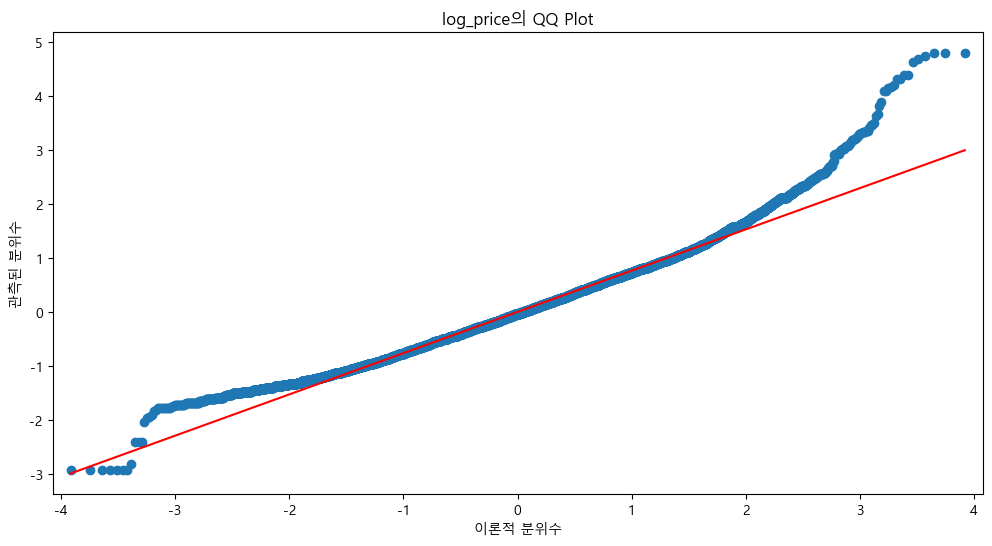

In [ ]:
#정규성 분석 - QQ plot
 # 실무에서는 모델의 잔차를 이용해서 QQ plot을 많이 그린다고 함.
 # resid: 모델의 잔차(residuals)는 실제 관측값과 모델이 예측한 값의 차이를 나타내는 값
        # 잔차: 모델이 데이터를 얼마나 잘 설명하는지를 평가하는데 사용 > 정규분포 따름 = 모델이 데이터에 잘 맞다고 할 수 있음.
QQ_plot = sm.qqplot(model.resid, line='s')
plt.title('log_price의 QQ Plot')
plt.xlabel('이론적 분위수')
plt.ylabel('관측된 분위수')
plt.show()

In [ ]:
# 정규성 분석 - Shapiro-Wilk 검정
s_stat_shapiro, p_value_shapiro = stats.shapiro(model.resid)

print(f"통계량: {s_stat_shapiro}, p-value: {p_value_shapiro}")

if p_value_shapiro < 0.05:
    print("결과: p-value가 0.05보다 작으므로 정규성을 따르지 않습니다. (비모수 검정 필요!)")
else:
    print("결과: 정규성을 따릅니다.")

통계량: 0.9825112832567676, p-value: 4.5523003623015795e-45
결과: p-value가 0.05보다 작으므로 정규성을 따르지 않습니다. (비모수 검정 필요!)


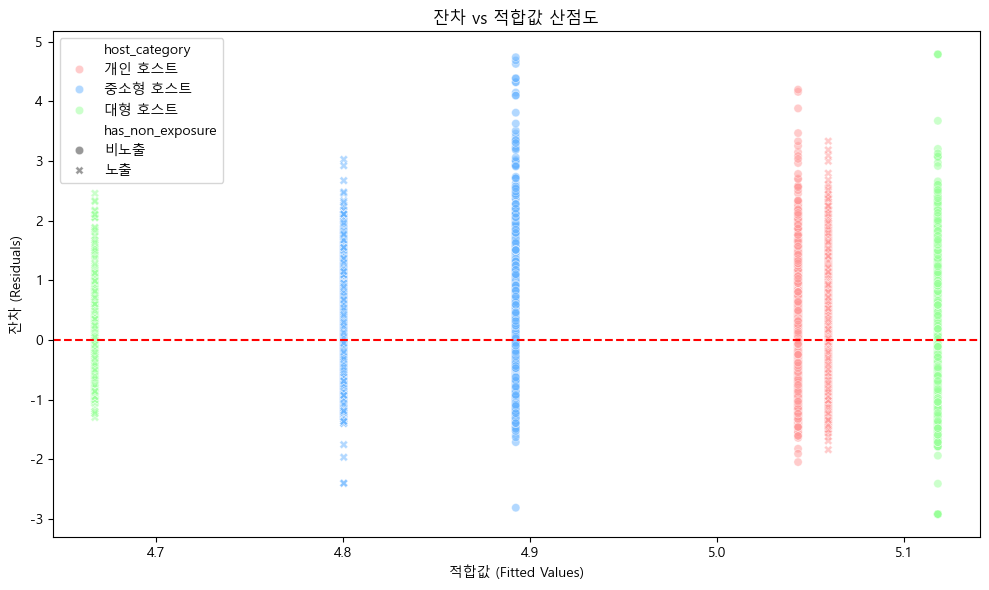

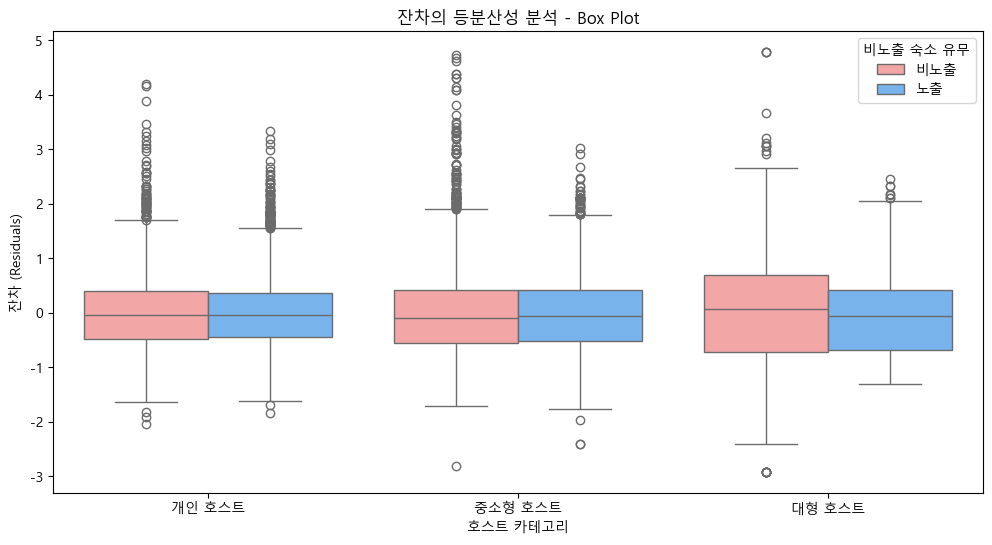

In [ ]:
# 등분산성 분석 - 그래프 그리기
df_cleaned_copy['residuals'] = model.resid
df_cleaned_copy['fitted'] = model.fittedvalues

# 산점도
plt.figure(figsize=(10, 6))
sns.scatterplot(x='fitted', y='residuals', style='has_non_exposure', hue='host_category', data=df_cleaned_copy, alpha=0.5, palette=['#ff9999','#66b3ff','#99ff99'])
plt.axhline(0, color='red', linestyle='--')
plt.title('잔차 vs 적합값 산점도')
plt.xlabel('적합값 (Fitted Values)')
plt.ylabel('잔차 (Residuals)')
plt.tight_layout()
plt.show()

# box plot
plt.figure(figsize=(12, 6))
sns.boxplot(x='host_category', y='residuals', hue='has_non_exposure', data=df_cleaned_copy, palette=['#ff9999', '#66b3ff'])
plt.title('잔차의 등분산성 분석 - Box Plot')
plt.xlabel('호스트 카테고리')
plt.ylabel('잔차 (Residuals)')
plt.legend(title='비노출 숙소 유무')
plt.show()

In [ ]:
# 두 컬럼을 합쳐서 새로운 그룹 컬럼 생성
df_cleaned_copy['group_combined'] = df_cleaned_copy['host_category'] + "_" + df_cleaned_copy['has_non_exposure']

# 어떤 그룹들이 생겼는지 확인해보기
print(df_cleaned_copy['group_combined'].unique())

<StringArray>
[ '개인 호스트_비노출',   '개인 호스트_노출',  '중소형 호스트_노출', '중소형 호스트_비노출',  '대형 호스트_비노출',
   '대형 호스트_노출']
Length: 6, dtype: str


In [ ]:
# 각 그룹에 데이터가 몇 개씩 있는지 확인하기
print(df_cleaned_copy['group_combined'].value_counts())

group_combined
대형 호스트_비노출     6251
개인 호스트_노출      4547
중소형 호스트_비노출    4473
개인 호스트_비노출     3420
중소형 호스트_노출     3185
대형 호스트_노출       432
Name: count, dtype: int64


In [ ]:
# 비모수 검정 - Kruskal-Wallis H-test
# 데이터 그룹으로 나누기
g1= group_individual_No = df_cleaned_copy[df_cleaned_copy['group_combined'] == '개인 호스트_비노출']['log_price']
g2 = group_individual_Yes = df_cleaned_copy[df_cleaned_copy['group_combined'] == '개인 호스트_노출']['log_price']
g3 = group_small_medium_No = df_cleaned_copy[df_cleaned_copy['group_combined'] == '중소형 호스트_비노출']['log_price']
g4 = group_small_medium_Yes = df_cleaned_copy[df_cleaned_copy['group_combined'] == '중소형 호스트_노출']['log_price']
g5 = group_large_No = df_cleaned_copy[df_cleaned_copy['group_combined'] == '대형 호스트_비노출']['log_price']
g6 = group_large_Yes = df_cleaned_copy[df_cleaned_copy['group_combined'] == '대형 호스트_노출']['log_price']

# Kruskal-Wallis H-test 수행
stat, p_value = stats.kruskal(g1, g2, g3, g4, g5, g6)
print(f"Kruskal-Wallis H-test 통계량: {stat}, p-value: {p_value}")

if p_value < 0.05:
    print("결과: p-value가 0.05보다 작으므로 그룹 간에 유의미한 차이가 있습니다.")
else:
    print("결과: 그룹 간에 유의미한 차이가 없습니다.")

Kruskal-Wallis H-test 통계량: 660.5247827602107, p-value: 1.6806966150775281e-140
결과: p-value가 0.05보다 작으므로 그룹 간에 유의미한 차이가 있습니다.


                개인 호스트_노출    개인 호스트_비노출     대형 호스트_노출    대형 호스트_비노출  \
개인 호스트_노출    1.000000e+00  1.000000e+00  6.667133e-26  9.545502e-03   
개인 호스트_비노출   1.000000e+00  1.000000e+00  9.581693e-22  9.775141e-06   
대형 호스트_노출    6.667133e-26  9.581693e-22  1.000000e+00  2.697029e-33   
대형 호스트_비노출   9.545502e-03  9.775141e-06  2.697029e-33  1.000000e+00   
중소형 호스트_노출   1.264283e-54  1.883171e-38  7.248419e-03  9.725857e-86   
중소형 호스트_비노출  2.147644e-35  2.733252e-22  6.051516e-07  1.694230e-63   

               중소형 호스트_노출   중소형 호스트_비노출  
개인 호스트_노출    1.264283e-54  2.147644e-35  
개인 호스트_비노출   1.883171e-38  2.733252e-22  
대형 호스트_노출    7.248419e-03  6.051516e-07  
대형 호스트_비노출   9.725857e-86  1.694230e-63  
중소형 호스트_노출   1.000000e+00  3.812019e-04  
중소형 호스트_비노출  3.812019e-04  1.000000e+00  


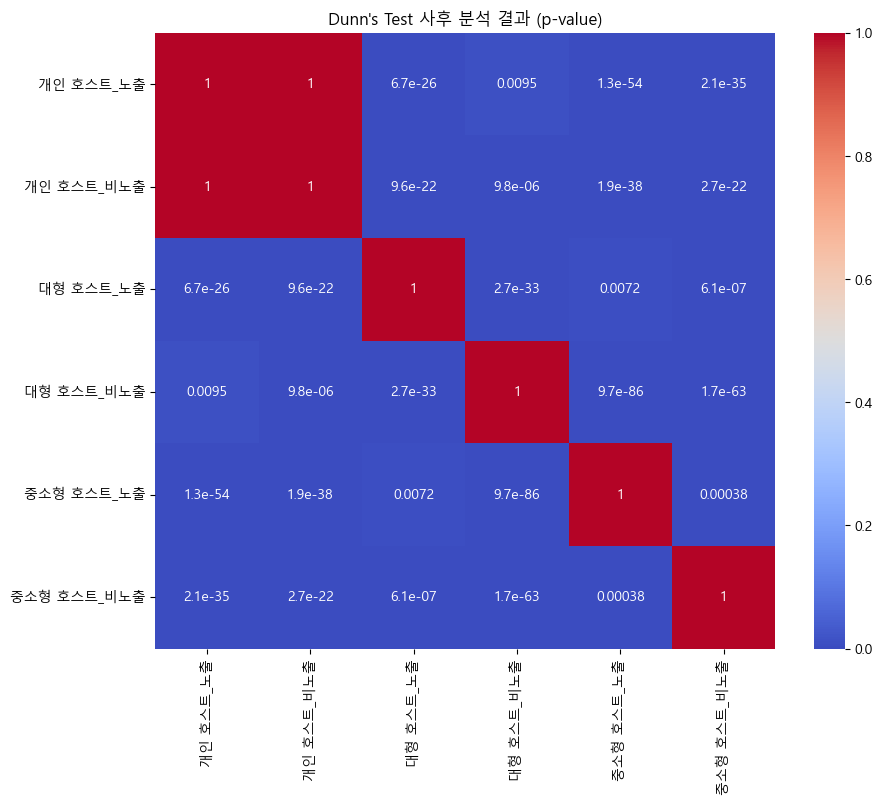

In [ ]:
# 사후분석 진행 (Dunn's test) - 어떤 그룹끼리 진짜 차이가 나는지 확인
import scikit_posthocs as sp

posthoc = sp.posthoc_dunn(df_cleaned_copy, val_col='log_price', group_col='group_combined', p_adjust='bonferroni')
print(posthoc)

# 사후 분석 결과를 히트맵으로 만들기
plt.figure(figsize=(10, 8))
sns.heatmap(posthoc, annot=True, cmap='coolwarm', cbar=True)
plt.title("Dunn's Test 사후 분석 결과 (p-value)")
plt.show()

In [36]:
from itertools import combinations

# 1. 사후 분석 결과 데이터 (이미 계산된 posthoc_results를 사용합니다)
# 2. 분석할 그룹 이름 리스트
group_names = [
    '개인 호스트_노출', '개인 호스트_비노출', 
    '중소형 호스트_노출', '중소형 호스트_비노출', 
    '대형 호스트_노출', '대형 호스트_비노출'
]

# 3. 모든 조합을 자동으로 비교하여 출력
print("=== [전체 그룹 1:1 사후 분석 결과] ===")
for g1, g2 in combinations(group_names, 2):
    p_val = posthoc_results.loc[g1, g2] #
    
    print(f"[{g1}] vs [{g2}]")
    print(f"- p-value: {p_val:.4f}")
    
    if p_val < 0.05: #
        print("=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅")
    else:
        print("=> 결과: 차이가 유의미하지 않음 ❌")
    print("-" * 30)

=== [전체 그룹 1:1 사후 분석 결과] ===
[개인 호스트_노출] vs [개인 호스트_비노출]
- p-value: 1.0000
=> 결과: 차이가 유의미하지 않음 ❌
------------------------------
[개인 호스트_노출] vs [중소형 호스트_노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_노출] vs [중소형 호스트_비노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_노출] vs [대형 호스트_노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_노출] vs [대형 호스트_비노출]
- p-value: 0.0095
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_비노출] vs [중소형 호스트_노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_비노출] vs [중소형 호스트_비노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_비노출] vs [대형 호스트_노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[개인 호스트_비노출] vs [대형 호스트_비노출]
- p-value: 0.0000
=> 결과: 두 그룹 간 가격 차이가 유의미함 ✅
------------------------------
[중소형 호스트_노출] vs [중소형 호스트_비노출

# 다음 분석 내용은..?
calculated_host_listings_count_entire_homes => 독채/아파트
calculated_host_listings_count_private_rooms => 개인실 수(거실/화장실 공유)
calculated_host_listings_count_shared_rooms => 다인실 수(게스트 하우스)

=>  1) 가격 
    2) 평점 

In [ ]:
# calculated_host_listings_count_entire_homes, calculated_host_listings_count_private_rooms, calculated_host_listings_count_shared_rooms의 가격측면에서의 차이 분석
entire_homes = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_entire_homes'] > 0]['price']
private_rooms = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_private_rooms'] > 0]['price']
shared_rooms = df_cleaned_copy[df_cleaned_copy['calculated_host_listings_count_shared_rooms'] > 0]['price']


# 히트맵을 통한 상관관계 분석
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned_copy[['price', 'calculated_host_listings_count_entire_homes', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms']].corr(), annot=True, cmap='coolwarm')
plt.title('price와 숙소 유형별 호스트 숙소 수 간의 상관관계', fontsize=16)
plt.show()